In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell A — Imports & Configuration (v9)
# ══════════════════════════════════════════════════════════════════════════════

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

# ── Optional: PyTorch Geometric ────────────────────────────────────────────────
try:
    from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv
    HAS_PYG = True
    print("✓ PyTorch Geometric available")
except ImportError:
    HAS_PYG = False
    print("✗ PyTorch Geometric not found — run: pip install torch-geometric")

warnings.filterwarnings("ignore", category=UserWarning)

# ── Canonical configuration (must match the pipeline) ──────────────────────────
START_MONTH = "2014-01"
END_MONTH   = "2025-11"
MONTHLY_IDX = pd.date_range(START_MONTH, END_MONTH, freq="MS")

COUNTRIES = [
    "AT","BE","BG","CY","CZ","DE","DK","EE","EL",
    "ES","FI","FR","HR","HU","IE","IT","LT","LU",
    "LV","MT","NL","PL","PT","RO","SE","SI","SK",
]

COUNTRY_IDX = {c: i for i, c in enumerate(COUNTRIES)}
N = len(COUNTRIES)  # 27

ALL_CATS = [
    "TOTAL", "Food_drinks_tobacco", "Raw_materials", 
    "Energy", "Chemicals", "Machinery_vehicles", "Other_manufactured",
]
N_CATS = len(ALL_CATS)  # 7

CEPII_COLS = [
    "comlang_ethno", "contig", "smctry",
    "dist", "distcap", "distw", "distwces"
]

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path("C:/Users/diede/Downloads/FILES FROM FULL DATA PIPELINE RUN")

MAIN_DATA_DIR = DATA_DIR / "main_data"
NODE_DIR      = DATA_DIR / "NodeFeatures" / "Second Try"
EDGE_DIR      = DATA_DIR / "edge_features"
GRAPH_DIR     = DATA_DIR / "graph_features"

IMPUTED_TRADE_CSV = MAIN_DATA_DIR / "eu_intra_trade_sitc_imputed.csv"

# ── Experiment hyperparameters ─────────────────────────────────────────────────
HIDDEN_DIM = 64        # node embedding dimension
N_EPOCHS   = 50        # epochs per validation run
LR         = 3e-4      # fixed learning rate
GRAD_CLIP  = 1.0       # stabilises GATv2 / TransformerConv early steps

HEADS       = 4
K_NEIGHBORS = 6
LOG_NODE_FEATURES = True

# ── GUIDE adaptation parameters ────────────────────────────────────────────────
ALPHA = 0.2
RECON_EPOCHS   = 50
ANOMALY_THRESH = 3.0   
SYNTH_MULT     = 5.0   
N_SYNTH        = 500   # Increased for robust Recall@K relevance

# ── Known event windows (soft labels) ──────────────────────────────────────────
COVID_WINDOW   = ("2020-04", "2020-09")
UKRAINE_WINDOW = ("2022-03", "2022-12")
ENERGY_IMPORTERS = {"DE", "IT", "PL", "FR", "HU", "SK"}

SEED    = 42
SEQ_LEN = 6 

# Adjusted boundaries so events fall strictly into validation
TRAIN_END = pd.Timestamp("2019-12-01")
VAL_END   = pd.Timestamp("2023-12-01")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device       : {DEVICE}")
print(f"Monthly index: {MONTHLY_IDX[0].date()} → {MONTHLY_IDX[-1].date()} ({len(MONTHLY_IDX)} periods)")
print(f"Countries    : {N} | Categories: {N_CATS} | Directed edges: {N * (N - 1)}")

c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 

✓ PyTorch Geometric available
Device       : cpu
Monthly index: 2014-01-01 → 2025-11-01 (143 periods)
Countries    : 27 | Categories: 7 | Directed edges: 702


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell B — Load All CSVs
# Data is already fully clean — no imputation needed.
# ══════════════════════════════════════════════════════════════════════════════

# ── B.1 Trade CSV ─────────────────────────────────────────────────────────────
df_trade = pd.read_csv(IMPUTED_TRADE_CSV)
df_trade["time"] = pd.to_datetime(df_trade["time"])
print(f"── Trade CSV ──")
print(f"  Shape      : {df_trade.shape}")
print(f"  Time range : {df_trade['time'].min().date()} → {df_trade['time'].max().date()}")
print(f"  Reporters  : {sorted(df_trade['reporter'].unique())}")
assert df_trade.isna().sum().sum() == 0, "NaNs in trade CSV!"
print(f"  NaNs       : 0 ✓\n")

# ── B.2 Node feature CSVs (T × 27 each) ──────────────────────────────────────
node_csv_paths = sorted(NODE_DIR.glob("*.csv"))
assert node_csv_paths, f"No node CSVs found in {NODE_DIR}"

node_dfs = {}   # stem → DataFrame(T, 27)
for p in node_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    node_dfs[p.stem] = df

total_node_nans = sum(df.isna().sum().sum() for df in node_dfs.values())
print(f"── Node feature CSVs ──")
print(f"  Files loaded : {len(node_dfs)}")
print(f"  Total NaNs   : {total_node_nans}")
assert total_node_nans == 0, f"Found {total_node_nans} NaNs in node features!"
print(f"  ✓ All clean\n")

# ── B.3 Graph feature CSVs (EURIBOR, VSTOXX — broadcast to all 27 cols) ──────
graph_csv_paths = sorted(GRAPH_DIR.glob("*.csv"))
graph_series = {}   # stem → Series(T,)

for p in graph_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    assert df.std(axis=1).max() < 1e-9, f"{p.name}: columns are not identical broadcasts!"
    graph_series[p.stem] = df.iloc[:, 0].rename(p.stem)

print(f"── Graph feature CSVs ──")
print(f"  Files loaded : {len(graph_series)}  → {list(graph_series.keys())}\n")

# ── B.4 Edge feature CSV (CEPII bilateral static) ─────────────────────────────
edge_csv = EDGE_DIR / "eu27_bilateral_static_features.csv"
assert edge_csv.exists(), f"Edge feature CSV not found at {edge_csv}"
df_edge = pd.read_csv(edge_csv)
df_edge["time"] = pd.to_datetime(df_edge["time"])
print(f"── Edge feature CSV ──")
print(f"  Shape  : {df_edge.shape}")
print(f"  Cols   : {list(df_edge.columns)}")

── Trade CSV ──
  Shape      : (100262, 10)
  Time range : 2014-01-01 → 2025-11-01
  Reporters  : ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
  NaNs       : 0 ✓

── Node feature CSVs ──
  Files loaded : 35
  Total NaNs   : 0
  ✓ All clean

── Graph feature CSVs ──
  Files loaded : 2  → ['euribor3m_monthly', 'vstoxx_monthly']

── Edge feature CSV ──
  Shape  : (100386, 11)
  Cols   : ['Unnamed: 0', 'time', 'reporter', 'partner', 'comlang_ethno', 'contig', 'smctry', 'dist', 'distcap', 'distw', 'distwces']


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell C — Tensor Assembly
# ══════════════════════════════════════════════════════════════════════════════

# ── C.1 Align all sources to a common monthly index ───────────────────────────
common_time = MONTHLY_IDX
for stem, df in node_dfs.items():
    common_time = common_time.intersection(df.index)
for stem, s in graph_series.items():
    common_time = common_time.intersection(s.index)
trade_times = pd.DatetimeIndex(sorted(df_trade["time"].unique()))
common_time = common_time.intersection(trade_times)
T = len(common_time)
print(f"Common time range: {common_time[0].date()} → {common_time[-1].date()}  (T={T})")

# ── C.2 Node feature tensor (T, N, F_node) ────────────────────────────────────
node_arrays, node_feat_names = [], []
for stem, df in sorted(node_dfs.items()):
    arr = df.loc[common_time, COUNTRIES].values.astype(np.float32)   # (T, N)
    node_arrays.append(arr)
    node_feat_names.append(stem)
node_np = np.stack(node_arrays, axis=-1)   # (T, N, F_node)
F_node  = node_np.shape[2]

# ── C.3 Graph feature tensor → broadcast to all nodes ────────────────────────
graph_feat_names = sorted(graph_series.keys())
graph_np = np.stack(
    [graph_series[s].reindex(common_time).values.astype(np.float32) for s in graph_feat_names],
    axis=-1,
)   # (T, F_graph)
graph_broadcast    = np.repeat(graph_np[:, np.newaxis, :], N, axis=1)    # (T, N, F_graph)
node_plus_graph_np = np.concatenate([node_np, graph_broadcast], axis=-1)  # (T, N, F_total)
F_total = node_plus_graph_np.shape[2]

# ── C.4 Target tensor (T, E, C) ───────────────────────────────────────────────
edge_pairs = [(i, j) for i in range(N) for j in range(N) if i != j]   # 702 directed edges
E      = len(edge_pairs)
src_idx = [p[0] for p in edge_pairs]
dst_idx = [p[1] for p in edge_pairs]

target_np = np.full((T, N, N, N_CATS), np.nan, dtype=np.float32)
for t_idx, ts in enumerate(common_time):
    df_t = df_trade[df_trade["time"] == ts]
    for _, row in df_t.iterrows():
        ri = COUNTRY_IDX.get(row["reporter"])
        pi = COUNTRY_IDX.get(row["partner"])
        if ri is not None and pi is not None and ri != pi:
            target_np[t_idx, ri, pi, :] = [row[c] for c in ALL_CATS]

target_edge_np = target_np[:, src_idx, dst_idx, :]   # (T, E, C)

# ── C.5 Static edge features (E, F_edge) ──────────────────────────────────────
F_edge = len(CEPII_COLS)
df_edge_t0   = df_edge[df_edge["time"] == df_edge["time"].min()].copy()
edge_feat_map = {}
for _, row in df_edge_t0.iterrows():
    ri = COUNTRY_IDX.get(row["reporter"])
    pi = COUNTRY_IDX.get(row["partner"])
    if ri is not None and pi is not None and ri != pi:
        edge_feat_map[(ri, pi)] = [row[c] for c in CEPII_COLS]

edge_feat_np = np.zeros((E, F_edge), dtype=np.float32)
for e_idx, (i, j) in enumerate(edge_pairs):
    if (i, j) in edge_feat_map:
        edge_feat_np[e_idx] = edge_feat_map[(i, j)]

# ── C.6 Convert to tensors ────────────────────────────────────────────────────
node_feat_tensor = torch.tensor(node_plus_graph_np, dtype=torch.float32)   # (T, N, F_total)
edge_feat_tensor = torch.tensor(edge_feat_np,       dtype=torch.float32)   # (E, F_edge)
target_tensor    = torch.tensor(target_edge_np,     dtype=torch.float32)   # (T, E, C)

print(f"\n✓ Tensor assembly complete")
print(f"  node_feat_tensor : {node_feat_tensor.shape}  (T, N, F_total={F_total})")
print(f"  edge_feat_tensor : {edge_feat_tensor.shape}  (E={E}, F_edge={F_edge})")
print(f"  target_tensor    : {target_tensor.shape}  (T, E, C={N_CATS})")
print(f"  NaNs in node features: {torch.isnan(node_feat_tensor).sum().item()}")
print(f"  NaNs in targets      : {torch.isnan(target_tensor).sum().item()}")

Common time range: 2014-01-01 → 2025-11-01  (T=143)

✓ Tensor assembly complete
  node_feat_tensor : torch.Size([143, 27, 37])  (T, N, F_total=37)
  edge_feat_tensor : torch.Size([702, 7])  (E=702, F_edge=7)
  target_tensor    : torch.Size([143, 702, 7])  (T, E, C=7)
  NaNs in node features: 0
  NaNs in targets      : 868


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell D — Normalisation (v9)
# ══════════════════════════════════════════════════════════════════════════════

# D.1 Target-based temporal split (no boundary leak)
train_idx = [t for t in range(len(common_time)-1) if common_time[t+1] <= TRAIN_END]
val_idx   = [t for t in range(len(common_time)-1) if TRAIN_END < common_time[t+1] <= VAL_END]
test_idx  = [t for t in range(len(common_time)-1) if common_time[t+1] > VAL_END]
assert common_time[train_idx[-1]+1] <= TRAIN_END
print(f"Train {len(train_idx)} | Val {len(val_idx)} | Test {len(test_idx)}  ✓ no leak")

n_val = len(val_idx)

# D.2 Optional log of strictly-positive node features
if LOG_NODE_FEATURES:
    train_min = node_feat_tensor[train_idx].reshape(-1, F_total).min(dim=0).values
    log_mask  = train_min > 0
    nf_raw    = node_feat_tensor.clone()
    nf_raw[:, :, log_mask] = torch.log1p(node_feat_tensor[:, :, log_mask])
else:
    nf_raw = node_feat_tensor

# D.3 Per-node per-feature z-score (train only)
train_data = nf_raw[train_idx]
feat_mean  = train_data.mean(dim=0)        # (N, F)
feat_std   = train_data.std(dim=0)

# FIX: Prevent explosion on zero-variance features (e.g., constant macro vars pre-2020)
# Instead of clamping to 1e-8, we divide by 1.0 if variance is effectively zero.
feat_std[feat_std < 1e-5] = 1.0

node_feat_norm = (nf_raw - feat_mean) / feat_std   # (T, N, F)

# D.4 Edge features: log1p distances then min-max
DISTANCE_FEAT_COLS    = ["dist","distcap","distw","distwces"]
DISTANCE_FEAT_INDICES = [CEPII_COLS.index(c) for c in DISTANCE_FEAT_COLS]
ef = edge_feat_tensor.clone()
for ci in DISTANCE_FEAT_INDICES:
    ef[:, ci] = torch.log1p(ef[:, ci])
emin = ef.min(dim=0).values; emax = ef.max(dim=0).values
edge_feat_norm = (ef - emin) / (emax - emin).clamp(min=1e-5)   # (E, F_edge)

# D.5 Target: log1p → 99th-pct scale from train
target_log    = torch.log1p(target_tensor.clamp(min=0))
valid_tr_log  = target_log[train_idx][~torch.isnan(target_log[train_idx])]
TARGET_SCALE  = float(valid_tr_log.quantile(0.99))
target_scaled = target_log / TARGET_SCALE
print(f"TARGET_SCALE = {TARGET_SCALE:.4f}")

def detransform(x):
    t = torch.tensor(x) if not isinstance(x, torch.Tensor) else x
    return torch.expm1(t.clamp(min=-30) * TARGET_SCALE)

# D.6 Node feature reconstruction targets
import numpy as np
# Note: target_np and target_scaled share memory, modifying one modifies the other.
target_np    = target_scaled.numpy()   # (T, E, C)
node_np      = node_feat_norm.numpy()  # (T, N, F)
edge_np      = edge_feat_norm.numpy()  # (E, F_edge)
train_tgt_t  = [t+1 for t in train_idx]
val_tgt_t    = [t+1 for t in val_idx]
val_actual   = target_np[val_tgt_t]   # (n_val, E, C)

print("✓ Normalisation complete")

Train 71 | Val 48 | Test 23  ✓ no leak
TARGET_SCALE = 21.2149
✓ Normalisation complete


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell E — Ground Truth Anomaly Labels (v9)
# ══════════════════════════════════════════════════════════════════════════════

label_synth = np.zeros((n_val, E, N_CATS), dtype=bool)
label_event = np.zeros((n_val, E, N_CATS), dtype=bool)
synth_indices = []

np.random.seed(SEED)

# ── 1. Flow Spikes (Structural Anomaly) ──
for _ in range(N_SYNTH // 3):
    vi    = np.random.randint(0, n_val)
    e_idx = np.random.randint(0, E)
    c_idx = np.random.randint(0, N_CATS)
    t_tgt = val_idx[vi] + 1
    
    orig = float(target_scaled[t_tgt, e_idx, c_idx])
    if not np.isnan(orig) and orig > 0.05:
        # Randomly multiply or divide to simulate unexpected shocks/crashes
        mult = SYNTH_MULT if np.random.rand() > 0.5 else (1.0 / SYNTH_MULT)
        new_val = orig * mult
        target_scaled[t_tgt, e_idx, c_idx] = torch.tensor(new_val)
        label_synth[vi, e_idx, c_idx] = True
        synth_indices.append((vi, e_idx, c_idx))

# ── 2. Temporal Flow Swap (Temporal Anomaly) ──
for _ in range(N_SYNTH // 3):
    vi    = np.random.randint(1, n_val) # Ensure we have a t-1
    e_idx = np.random.randint(0, E)
    c_idx = np.random.randint(0, N_CATS)
    t_tgt = val_idx[vi] + 1
    t_prev = val_idx[vi-1] + 1
    
    orig_curr = float(target_scaled[t_tgt, e_idx, c_idx])
    orig_prev = float(target_scaled[t_prev, e_idx, c_idx])
    
    if not np.isnan(orig_curr) and not np.isnan(orig_prev) and abs(orig_curr - orig_prev) > 0.1:
        target_scaled[t_tgt, e_idx, c_idx] = torch.tensor(orig_prev)
        label_synth[vi, e_idx, c_idx] = True
        synth_indices.append((vi, e_idx, c_idx))

# ── 3. Node Feature Perturbation (Attribute Anomaly) ──
for _ in range(N_SYNTH - 2*(N_SYNTH // 3)):
    vi = np.random.randint(0, n_val)
    t_tgt = val_idx[vi] + 1
    n1, n2 = np.random.choice(N, 2, replace=False)
    
    # Swap attributes between two random countries for a single month
    temp_feat = node_feat_norm[t_tgt, n1, :].clone()
    node_feat_norm[t_tgt, n1, :] = node_feat_norm[t_tgt, n2, :]
    node_feat_norm[t_tgt, n2, :] = temp_feat
    
    node_np[t_tgt, n1, :] = node_feat_norm[t_tgt, n1, :].numpy()
    node_np[t_tgt, n2, :] = node_feat_norm[t_tgt, n2, :].numpy()
    
    # Flag all edges originating from or pointing to these perturbed nodes
    flagged_any = False
    for e_idx, (src_i, dst_i) in enumerate(edge_pairs):
        if src_i == n1 or dst_i == n1 or src_i == n2 or dst_i == n2:
            label_synth[vi, e_idx, :] = True
            if not flagged_any:
                synth_indices.append((vi, e_idx, 0)) # Store one representative marker for plotting
                flagged_any = True

print(f"Synthetic anomalies injected: ~{N_SYNTH} combined events")

# ── Event labels ───────────────────────────────────────────────────────────────
ENERGY_CAT_IDX = ALL_CATS.index("Energy")
for vi, t in enumerate(val_idx):
    ts = common_time[t + 1]
    if pd.Timestamp(COVID_WINDOW[0]) <= ts <= pd.Timestamp(COVID_WINDOW[1]):
        label_event[vi, :, :] = True
    if pd.Timestamp(UKRAINE_WINDOW[0]) <= ts <= pd.Timestamp(UKRAINE_WINDOW[1]):
        for e_idx, (src_i, dst_i) in enumerate(edge_pairs):
            if COUNTRIES[dst_i] in ENERGY_IMPORTERS:
                label_event[vi, e_idx, ENERGY_CAT_IDX] = True

label_combined   = label_synth | label_event
valid_mask_flat  = ~np.isnan(target_np[val_tgt_t]).reshape(-1)

print(f"Event labels: {int(label_event.sum()):,}  |  "
      f"Combined: {int(label_combined.sum()):,}  |  "
      f"Valid non-NaN cells: {valid_mask_flat.sum():,}")
print("✓ Ground truth ready")

Synthetic anomalies injected: ~500 combined events
Event labels: 31,044  |  Combined: 113,800  |  Valid non-NaN cells: 235,802
✓ Ground truth ready


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell F — Three Graph Topologies (v9)
# ══════════════════════════════════════════════════════════════════════════════

import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv

HAS_PYG            = True
EDGE_AWARE_CONVS   = {GATv2Conv, TransformerConv}
CONV_NEEDS_SL      = {GCNConv, GATv2Conv, TransformerConv}   # SAGEConv excluded
ARCH_LR            = {GCNConv:3e-4, GATv2Conv:1e-4, SAGEConv:3e-4, TransformerConv:1e-4}

edge_pair_to_idx = {pair: idx for idx, pair in enumerate(edge_pairs)}
edge_index_pred  = torch.tensor(
    [[i for i,j in edge_pairs],[j for i,j in edge_pairs]], dtype=torch.long
)

# KNN-composite: K nearest by mean of all CEPII similarity features
composite_score = {}
for e_idx, (i,j) in enumerate(edge_pairs):
    vec = edge_feat_norm[e_idx].clone()
    for ci in DISTANCE_FEAT_INDICES:
        vec[ci] = 1.0 - vec[ci]   # flip: low distance → high similarity
    composite_score[(i,j)] = float(vec.mean())

cepii_pairs = []
for i in range(N):
    by_score = sorted([(composite_score.get((i,j),-1.), j)
                       for j in range(N) if i!=j], reverse=True)[:K_NEIGHBORS]
    cepii_pairs.extend([(i,j) for _,j in by_score])
n_sparse = len(cepii_pairs)

# Random sparse (same edge count, one draw)
torch.manual_seed(SEED + 999)
perm_r      = torch.randperm(len(edge_pairs))[:n_sparse]
rand_pairs  = [edge_pairs[k] for k in perm_r.tolist()]

ADJ_CONFIGS = {
    "Complete" : edge_pairs,     # all 702
    "CEPII-KNN": cepii_pairs,    # K×N = 162
    "Random"   : rand_pairs,     # 162, no structure
}

def build_mp_graph(pairs, conv_cls):
    """Build (edge_index, edge_attr) tensors; add self-loops where literature requires."""
    ei = torch.tensor([[p[0] for p in pairs],[p[1] for p in pairs]], dtype=torch.long)
    ea = torch.stack([edge_feat_norm[edge_pair_to_idx[p]] for p in pairs])
    if conv_cls in CONV_NEEDS_SL:
        sl = torch.arange(N, dtype=torch.long)
        ei = torch.cat([ei, torch.stack([sl, sl])], dim=1)
        ea = torch.cat([ea, torch.zeros(N, F_edge)], dim=0)
    return ei, ea

print("Adjacency edge counts (excl. self-loops):")
for name, pairs in ADJ_CONFIGS.items():
    print(f"  {name:<12}: {len(pairs):4d}  avg out-degree {len(pairs)/N:.1f}")
print("✓ Adjacency setup complete")

Adjacency edge counts (excl. self-loops):
  Complete    :  702  avg out-degree 26.0
  CEPII-KNN   :  162  avg out-degree 6.0
  Random      :  162  avg out-degree 6.0
✓ Adjacency setup complete


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell G — GUIDE-Inspired Dual GNN Autoencoder  (v8)
#
# GUIDE (Yuan et al. 2024) uses dual autoencoders:
#   AE_attr   : GCN encoder → reconstruct node attribute matrix X
#   AE_struct : GNA encoder → reconstruct higher-order structure matrix S
#   score(v)  = (1-α)||s - ŝ||² + α||x - x̂||²   [GUIDE eq. 14]
#
# Our edge-level adaptation:
#   AE_attr   : GNN encoder on node features → reconstruct node_feat_norm[t]
#               Catches: country-level attribute anomalies (e.g. economic shock)
#   AE_flow   : GNN encoder on node features → reconstruct target_scaled[t,e,c]
#               (current-timestep flows, not t+1)
#               Catches: structural flow anomalies (flow inconsistent with graph)
#   score(e,t) = (1-α) · calibrated_flow_error(e,t)
#              + α     · calibrated_attr_error_edge(e,t)
#
# Where calibrated = z-scored by per-(edge/node) training statistics.
# This extends GUIDE's calibration to temporal data (Malhotra et al. 2015).
#
# Architecture choices: same GNN backbone (GCNConv default; swappable).
# add_self_loops=False in all constructors — managed by build_mp_graph.
# ══════════════════════════════════════════════════════════════════════════════

def _build_conv(conv_cls, in_h, out_h, heads=4, edge_dim=None):
    ed = edge_dim if edge_dim is not None else F_edge
    
    if conv_cls is TransformerConv:
        # TransformerConv: No add_self_loops argument
        return conv_cls(in_h, out_h // heads, heads=heads, 
                        edge_dim=ed, concat=True)
    
    elif conv_cls is GATv2Conv:
        # GATv2Conv: supports add_self_loops=False
        return conv_cls(in_h, out_h // heads, heads=heads, 
                        edge_dim=ed, concat=True, add_self_loops=False)
    
    elif conv_cls is GCNConv:
        return conv_cls(in_h, out_h, add_self_loops=False)
    
    else: # SAGEConv
        return conv_cls(in_h, out_h)


class GUIDENodeAttrAE(nn.Module):
    def __init__(self, conv_cls, in_ch, H=64, dropout=0.1):
        super().__init__()
        self.conv_cls = conv_cls
        
        # Use the helper to build layers safely
        self.enc = nn.ModuleList([
            _build_conv(conv_cls, in_ch, H, heads=HEADS), # Layer 0
            _build_conv(conv_cls, H, H, heads=HEADS),     # Layer 1
            _build_conv(conv_cls, H, H, heads=HEADS)      # Layer 2
        ])

        self.lns  = nn.ModuleList([nn.LayerNorm(H) for _ in range(3)])
        self.dec  = _build_conv(conv_cls, H, H, heads=HEADS)
        self.dec_proj = nn.Linear(H, in_ch)
        self.drop = nn.Dropout(dropout)

    def _conv(self, conv, h, ei, ea):
        return conv(h, ei, edge_attr=ea) if self.conv_cls in EDGE_AWARE_CONVS else conv(h, ei)

    def encode(self, x, ei, ea):
        h = x
        for conv, ln in zip(self.enc, self.lns):
            r = h if h.shape[-1] == ln.normalized_shape[0] else None
            h = F.relu(self._conv(conv, h, ei, ea))
            h = ln(h); h = self.drop(h)
            if r is not None: h = h + r
        return h

    def decode(self, z, ei, ea):
        h = F.relu(self._conv(self.dec, z, ei, ea))
        return self.dec_proj(h)

    def forward(self, x, ei, ea):
        z     = self.encode(x, ei, ea)
        x_hat = self.decode(z, ei, ea)
        return x_hat, z


class GUIDEEdgeFlowAE(nn.Module):
    def __init__(self, conv_cls, in_ch, H=64, n_out=7, edge_dim=7, dropout=0.1):
        super().__init__()
        self.conv_cls = conv_cls
        
        # Build encoders safely using helper
        self.enc0 = _build_conv(conv_cls, in_ch, H, heads=HEADS, edge_dim=edge_dim)
        self.enc1 = _build_conv(conv_cls, H, H, heads=HEADS, edge_dim=edge_dim)

        self.ln0   = nn.LayerNorm(H)
        self.ln1   = nn.LayerNorm(H)
        pred_in    = 2*H + edge_dim
        self.flow_head = nn.Sequential(
            nn.Linear(pred_in, H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H//2),    nn.ReLU(),
            nn.Linear(H//2, n_out)
        )
        self.drop = nn.Dropout(dropout)

    def _conv(self, conv, h, ei, ea):
        return conv(h, ei, edge_attr=ea) if self.conv_cls in EDGE_AWARE_CONVS else conv(h, ei)

    def encode(self, x, ei, ea):
        h = F.relu(self._conv(self.enc0, x, ei, ea))
        h = self.ln0(h); h = self.drop(h)
        r = h
        h = F.relu(self._conv(self.enc1, h, ei, ea))
        h = self.ln1(h); h = self.drop(h); h = h + r
        return h

    def forward(self, x, ei_mp, ea_mp, ei_pred, ea_pred):
        z    = self.encode(x, ei_mp, ea_mp)
        s, d = ei_pred
        feat = torch.cat([z[s], z[d], ea_pred], dim=-1)
        return self.flow_head(feat)

print("GUIDENodeAttrAE and GUIDEEdgeFlowAE defined")
for cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
    na = GUIDENodeAttrAE(cls, F_total, HIDDEN_DIM)
    fa = GUIDEEdgeFlowAE(cls, F_total, HIDDEN_DIM, N_CATS, F_edge)
    n1 = sum(p.numel() for p in na.parameters() if p.requires_grad)
    n2 = sum(p.numel() for p in fa.parameters() if p.requires_grad)
    print(f"  {cls.__name__:<20}  NodeAttrAE={n1:,}  EdgeFlowAE={n2:,}  total={n1+n2:,}")

GUIDENodeAttrAE and GUIDEEdgeFlowAE defined
  GCNConv               NodeAttrAE=17,701  EdgeFlowAE=17,863  total=35,564
  GATv2Conv             NodeAttrAE=34,917  EdgeFlowAE=25,607  total=60,524
  SAGEConv              NodeAttrAE=32,357  EdgeFlowAE=24,327  total=56,684
  TransformerConv       NodeAttrAE=64,229  EdgeFlowAE=38,535  total=102,764


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H — Baseline Anomaly Detection Methods (v9)
# ══════════════════════════════════════════════════════════════════════════════

import warnings, time
from joblib import Parallel, delayed
from statsmodels.tsa.stl._stl import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

def fill_series(s):
    s = s.copy().astype(np.float64)
    if np.isnan(s).all(): return np.zeros(len(s))
    idx = np.arange(len(s)); ok = ~np.isnan(s)
    return np.interp(idx, idx[ok], s[ok])

# ── 1. LOF ──
print("1/7  LOF (per-edge feature vectors)...")
def fit_lof(e):
    src_i, dst_i = edge_pairs[e]
    X_tr, X_va   = [], []
    for t in train_idx:
        t_tgt = t + 1
        lag1 = target_np[max(0,t_tgt-1), e, :]
        lag3 = target_np[max(0,t_tgt-3), e, :]
        feat = np.concatenate([lag1, lag3, node_np[t_tgt,src_i], node_np[t_tgt,dst_i], edge_np[e]])
        X_tr.append(np.nan_to_num(feat))
    for t in val_idx:
        t_tgt = t + 1
        lag1 = target_np[max(0,t_tgt-1), e, :]
        lag3 = target_np[max(0,t_tgt-3), e, :]
        feat = np.concatenate([lag1, lag3, node_np[t_tgt,src_i], node_np[t_tgt,dst_i], edge_np[e]])
        X_va.append(np.nan_to_num(feat))
    if len(X_tr) < 20: return e, np.zeros(n_val)
    sc  = StandardScaler().fit(X_tr)
    clf = LocalOutlierFactor(n_neighbors=min(20, len(X_tr)-1), novelty=True)
    clf.fit(sc.transform(X_tr))
    scores_v = -clf.score_samples(sc.transform(X_va))
    return e, scores_v

t0 = time.time()
lof_raw = np.full((n_val, E), np.nan)
for e, sc in Parallel(n_jobs=-1, prefer='threads')(delayed(fit_lof)(e) for e in range(E)):
    lof_raw[:, e] = sc
lof_scores = np.repeat(lof_raw[:,:,np.newaxis], N_CATS, axis=2)
print(f"   done  {time.time()-t0:.1f}s")

# ── 2. AE_MLP ──
print("2/7  AE_MLP (plain autoencoder, no graph structure)...")
class MLP_AE(nn.Module):
    def __init__(self, in_dim, H=64, out_dim=None):
        super().__init__()
        out_dim = out_dim or in_dim
        self.enc = nn.Sequential(nn.Linear(in_dim,H), nn.ReLU(),
                                  nn.Linear(H, H//2), nn.ReLU())
        self.dec = nn.Sequential(nn.Linear(H//2,H), nn.ReLU(),
                                  nn.Linear(H, out_dim))
    def forward(self, x): return self.dec(self.enc(x))

F_mlp = N_CATS*3 + F_total*2 + F_edge

def make_mlp_inputs(t_steps):
    rows = []
    for t in t_steps:
        t_tgt = t + 1
        tgt   = target_np[t_tgt, :, :]   
        lag1  = target_np[max(0,t_tgt-1), :, :]
        lag2  = target_np[max(0,t_tgt-2), :, :]
        for e in range(E):
            si, di = edge_pairs[e]
            feat = np.concatenate([
                np.nan_to_num(tgt[e]), np.nan_to_num(lag1[e]), np.nan_to_num(lag2[e]),
                node_np[t_tgt, si], node_np[t_tgt, di], edge_np[e]
            ])
            rows.append(feat.astype(np.float32))
    return np.array(rows)

X_tr_mlp = make_mlp_inputs(train_idx)
sc_mlp   = StandardScaler().fit(X_tr_mlp)
X_tr_sc  = torch.tensor(sc_mlp.transform(X_tr_mlp), dtype=torch.float32)

torch.manual_seed(SEED)
mlp_ae  = MLP_AE(F_mlp, HIDDEN_DIM, F_mlp)
opt_mlp = Adam(mlp_ae.parameters(), lr=1e-3, weight_decay=1e-5)
crit    = nn.MSELoss()

for ep in range(RECON_EPOCHS):
    mlp_ae.train(); opt_mlp.zero_grad()
    out  = mlp_ae(X_tr_sc)
    loss = crit(out, X_tr_sc)
    loss.backward(); opt_mlp.step()

mlp_ae.eval()
mlp_scores = np.full((n_val, E, N_CATS), np.nan)
with torch.no_grad():
    for vi, t in enumerate(val_idx):
        t_tgt = t + 1
        for e in range(E):
            si, di = edge_pairs[e]
            feat = np.concatenate([
                np.nan_to_num(target_np[t_tgt, e, :]),
                np.nan_to_num(target_np[max(0,t_tgt-1), e, :]),
                np.nan_to_num(target_np[max(0,t_tgt-2), e, :]),
                node_np[t_tgt,si], node_np[t_tgt,di], edge_np[e]
            ]).astype(np.float32)
            x_in = torch.tensor(sc_mlp.transform(feat.reshape(1,-1)), dtype=torch.float32)
            recon = mlp_ae(x_in)
            raw = (x_in - recon).abs().numpy()[0, :N_CATS]
            mlp_scores[vi, e, :] = raw
print("   done")

print("3/7  DOMINANT placeholder (GCN-only flow AE, trained in Cell I)")

# ── 4. Z-score ──
print("4/7  Z-score...")
zscore_scores = np.full((n_val, E, N_CATS), np.nan)
for e in range(E):
    for c in range(N_CATS):
        tr = target_np[train_tgt_t, e, c]; tr = tr[~np.isnan(tr)]
        if len(tr) < 2: continue
        mu, sig = tr.mean(), tr.std() + 1e-8
        for vi, t_tgt in enumerate(val_tgt_t):
            v = target_np[t_tgt, e, c]
            zscore_scores[vi, e, c] = 0.0 if np.isnan(v) else abs((v - mu) / sig)

# ── 5. EWMA ──
print("5/7  EWMA...")
def fit_ewma(e, c, alpha=0.3):
    full = fill_series(target_np[:, e, c])
    ewma = np.zeros(len(full)); ewma[0] = full[0]
    for i in range(1, len(full)): ewma[i] = alpha*full[i] + (1-alpha)*ewma[i-1]
    sigma = full[train_tgt_t].std() + 1e-8
    return e, c, [abs((full[t_tgt] - ewma[t_tgt]) / sigma) for t_tgt in val_tgt_t]

ewma_scores = np.full((n_val, E, N_CATS), np.nan)
for e, c, sc in Parallel(n_jobs=-1, prefer='threads')(
        delayed(fit_ewma)(e,c) for e in range(E) for c in range(N_CATS)):
    ewma_scores[:, e, c] = sc

# ── 6. STL residual ──
print("6/7  STL (parallel)...")
def fit_stl(e, c):
    full = fill_series(target_np[:, e, c])
    if np.std(full) < 1e-8: return e, c, [0.]*n_val
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            rem   = STL(full, period=12, robust=True).fit().resid
            tr_q  = np.percentile(rem[train_tgt_t], 75) - np.percentile(rem[train_tgt_t], 25) + 1e-8
            return e, c, [abs(rem[t_tgt])/tr_q for t_tgt in val_tgt_t]
    except: return e, c, [0.]*n_val

t0 = time.time()
stl_scores = np.full((n_val, E, N_CATS), np.nan)
for e, c, sc in Parallel(n_jobs=-1, prefer='threads')(
        delayed(fit_stl)(e,c) for e in range(E) for c in range(N_CATS)):
    stl_scores[:, e, c] = sc
print(f"   done  {time.time()-t0:.1f}s")

# ── 7. ARIMA residual ──
print("7/7  ARIMA (parallel)...")
def fit_arima(e, c):
    tr_s = fill_series(target_np[train_tgt_t, e, c])
    if np.std(tr_s) < 1e-8: return e, c, [0.]*n_val
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fit   = SARIMAX(tr_s, order=(1,1,1), trend='n',
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(
                                disp=False, maxiter=100, method='lbfgs')
            sigma = fit.resid.std() + 1e-8
            fc    = list(fit.forecast(n_val))
            return e, c, [abs((target_np[t_tgt,e,c]-fc[vi])/sigma)
                          if not np.isnan(target_np[t_tgt,e,c]) else 0.
                          for vi, t_tgt in enumerate(val_tgt_t)]
    except: return e, c, [0.]*n_val

t0 = time.time()
arima_scores = np.full((n_val, E, N_CATS), np.nan)
for e, c, sc in Parallel(n_jobs=-1, prefer='threads')(
        delayed(fit_arima)(e,c) for e in range(E) for c in range(N_CATS)):
    arima_scores[:, e, c] = sc
print(f"   done  {time.time()-t0:.1f}s")

baseline_scores = {
    "LOF"        : lof_scores,
    "AE-MLP"     : mlp_scores,
    "Z-score"    : zscore_scores,
    "EWMA"       : ewma_scores,
    "STL-resid"  : stl_scores,
    "ARIMA-resid": arima_scores,
}
print("✓ Baselines complete")

1/7  LOF (per-edge feature vectors)...
   done  8.3s
2/7  AE_MLP (plain autoencoder, no graph structure)...
   done
3/7  DOMINANT placeholder (GCN-only flow AE, trained in Cell I)
4/7  Z-score...
5/7  EWMA...
6/7  STL (parallel)...
   done  102.3s
7/7  ARIMA (parallel)...
   done  435.0s
✓ Baselines complete


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell I — Train GUIDE-GNN Dual AE + Compute Anomaly Scores (v9)
# ══════════════════════════════════════════════════════════════════════════════
RECON_EPOCHS = 500

def train_guide_gnn(conv_cls, adj_name, n_epochs=RECON_EPOCHS, verbose=True):
    pairs        = ADJ_CONFIGS[adj_name]
    lr           = ARCH_LR[conv_cls]
    ei_mp, ea_mp = build_mp_graph(pairs, conv_cls)
    ei_d  = ei_mp.to(DEVICE); ea_d  = ea_mp.to(DEVICE)
    ei_pd = edge_index_pred.to(DEVICE); ea_pd = edge_feat_norm.to(DEVICE)

    torch.manual_seed(SEED)
    node_ae = GUIDENodeAttrAE(conv_cls, F_total, HIDDEN_DIM).to(DEVICE)
    flow_ae = GUIDEEdgeFlowAE(conv_cls, F_total, HIDDEN_DIM, N_CATS, F_edge).to(DEVICE)
    opt     = Adam(list(node_ae.parameters()) + list(flow_ae.parameters()),
                   lr=lr, weight_decay=1e-5)
    crit    = nn.MSELoss()

    for epoch in range(1, n_epochs + 1):
        node_ae.train(); flow_ae.train()
        ep_loss = 0.
        for t in train_idx:
            t_tgt = t + 1
            x     = node_feat_norm[t_tgt].to(DEVICE)   # Predict flows exactly using current step features
            y_cur = target_scaled[t_tgt].to(DEVICE)    
            valid = ~torch.isnan(y_cur).any(dim=-1)

            opt.zero_grad()
            x_hat, _ = node_ae(x, ei_d, ea_d)
            L_attr   = crit(x_hat, x)

            y_hat  = flow_ae(x, ei_d, ea_d, ei_pd, ea_pd)
            L_flow = crit(y_hat[valid], y_cur[valid]) if valid.any() else torch.tensor(0.)

            loss = (1 - ALPHA) * L_flow + ALPHA * L_attr
            loss.backward()
            nn.utils.clip_grad_norm_(list(node_ae.parameters()) + list(flow_ae.parameters()), 1.0)
            opt.step()
            ep_loss += loss.item()

        if verbose and epoch % 10 == 0:
            node_ae.eval(); flow_ae.eval()
            vl = 0.
            with torch.no_grad():
                for t in val_idx:
                    t_tgt = t + 1
                    x     = node_feat_norm[t_tgt].to(DEVICE)
                    y_cur = target_scaled[t_tgt].to(DEVICE)
                    valid = ~torch.isnan(y_cur).any(dim=-1)
                    x_hat, _ = node_ae(x, ei_d, ea_d)
                    y_hat    = flow_ae(x, ei_d, ea_d, ei_pd, ea_pd)
                    la = crit(x_hat, x).item()
                    lf = crit(y_hat[valid], y_cur[valid]).item() if valid.any() else 0.
                    vl += (1-ALPHA)*lf + ALPHA*la
            print(f"  epoch {epoch:3d}  val_loss={vl/len(val_idx):.5f}")

    node_ae.eval(); flow_ae.eval()
    flow_resid_tr = np.full((len(train_idx), E, N_CATS), np.nan)
    attr_resid_tr = np.full((len(train_idx), N, F_total), np.nan)

    with torch.no_grad():
        for i, t in enumerate(train_idx):
            t_tgt   = t + 1
            x       = node_feat_norm[t_tgt].to(DEVICE)
            y_cur   = target_scaled[t_tgt].numpy()
            x_hat, _= node_ae(x, ei_d, ea_d)
            y_hat   = flow_ae(x, ei_d, ea_d, ei_pd, ea_pd)
            flow_resid_tr[i] = y_cur - y_hat.cpu().numpy()
            attr_resid_tr[i] = x.cpu().numpy() - x_hat.cpu().numpy()

    flow_mu  = np.nanmean(flow_resid_tr, axis=0)   
    flow_sig = np.nanstd(flow_resid_tr,  axis=0) + 1e-8
    attr_mu  = np.nanmean(attr_resid_tr, axis=0)   
    attr_sig = np.nanstd(attr_resid_tr,  axis=0) + 1e-8

    return node_ae, flow_ae, (flow_mu, flow_sig, attr_mu, attr_sig), ei_d, ea_d


def compute_guide_scores(node_ae, flow_ae, calib, ei_d, ea_d):
    flow_mu, flow_sig, attr_mu, attr_sig = calib
    node_ae.eval(); flow_ae.eval()
    ei_pd = edge_index_pred.to(DEVICE); ea_pd = edge_feat_norm.to(DEVICE)

    z_flow_arr  = np.full((n_val, E, N_CATS), np.nan)
    z_attr_edge = np.full((n_val, E), np.nan)

    with torch.no_grad():
        for vi, t in enumerate(val_idx):
            t_tgt   = t + 1
            x       = node_feat_norm[t_tgt].to(DEVICE)
            y_cur   = target_scaled[t_tgt].numpy()
            x_hat, _= node_ae(x, ei_d, ea_d)
            y_hat   = flow_ae(x, ei_d, ea_d, ei_pd, ea_pd)

            resid_f = y_cur - y_hat.cpu().numpy()
            z_f     = np.abs(resid_f - flow_mu) / flow_sig
            z_flow_arr[vi] = z_f

            resid_a   = x.cpu().numpy() - x_hat.cpu().numpy()   
            z_node    = np.mean(np.abs(resid_a - attr_mu) / attr_sig, axis=-1)   
            for e_idx, (si, di) in enumerate(edge_pairs):
                z_attr_edge[vi, e_idx] = 0.5 * (z_node[si] + z_node[di])

    z_attr_bc   = z_attr_edge[:, :, np.newaxis]   
    score_arr   = (1 - ALPHA) * z_flow_arr + ALPHA * z_attr_bc
    return score_arr, z_flow_arr, z_attr_edge


# ── DOMINANT baseline: EdgeFlowAE only ──
def train_dominant(conv_cls, adj_name, n_epochs=RECON_EPOCHS, verbose=False):
    pairs        = ADJ_CONFIGS[adj_name]
    ei_mp, ea_mp = build_mp_graph(pairs, conv_cls)
    ei_d = ei_mp.to(DEVICE); ea_d = ea_mp.to(DEVICE)
    ei_pd= edge_index_pred.to(DEVICE); ea_pd = edge_feat_norm.to(DEVICE)

    torch.manual_seed(SEED)
    model = GUIDEEdgeFlowAE(conv_cls, F_total, HIDDEN_DIM, N_CATS, F_edge).to(DEVICE)
    opt   = Adam(model.parameters(), lr=ARCH_LR[conv_cls], weight_decay=1e-5)
    crit  = nn.MSELoss()

    for epoch in range(1, n_epochs + 1):
        model.train()
        for t in train_idx:
            t_tgt = t + 1
            x     = node_feat_norm[t_tgt].to(DEVICE)
            y_cur = target_scaled[t_tgt].to(DEVICE)
            valid = ~torch.isnan(y_cur).any(dim=-1)
            if not valid.any(): continue
            opt.zero_grad()
            loss = crit(model(x, ei_d, ea_d, ei_pd, ea_pd)[valid], y_cur[valid])
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()

    model.eval()
    resid_tr = np.full((len(train_idx), E, N_CATS), np.nan)
    with torch.no_grad():
        for i, t in enumerate(train_idx):
            t_tgt = t + 1
            x    = node_feat_norm[t_tgt].to(DEVICE)
            pred = model(x, ei_d, ea_d, ei_pd, ea_pd).cpu().numpy()
            resid_tr[i] = target_scaled[t_tgt].numpy() - pred
    mu_d  = np.nanmean(resid_tr, axis=0); sig_d = np.nanstd(resid_tr, axis=0) + 1e-8

    scores = np.full((n_val, E, N_CATS), np.nan)
    with torch.no_grad():
        for vi, t in enumerate(val_idx):
            t_tgt = t + 1
            x    = node_feat_norm[t_tgt].to(DEVICE)
            pred = model(x, ei_d, ea_d, ei_pd, ea_pd).cpu().numpy()
            scores[vi] = np.abs(target_scaled[t_tgt].numpy() - pred - mu_d) / sig_d
    return scores

BEST_CONV = TransformerConv
BEST_ADJ  = "CEPII-KNN"

print(f"Training GUIDE dual AE: {BEST_CONV.__name__} + {BEST_ADJ}...")
node_ae, flow_ae, calib, ei_best, ea_best = train_guide_gnn(
    BEST_CONV, BEST_ADJ, n_epochs=RECON_EPOCHS, verbose=True
)
guide_scores, z_flow, z_attr_edge = compute_guide_scores(
    node_ae, flow_ae, calib, ei_best, ea_best
)

print(f"\nTraining DOMINANT ({BEST_CONV.__name__}, {BEST_ADJ})...")
dominant_scores = train_dominant(BEST_CONV, BEST_ADJ, verbose=False)

all_scores = {
    **baseline_scores,
    f"DOMINANT-{BEST_ADJ}"    : dominant_scores,
    f"GUIDE-{BEST_ADJ}"       : guide_scores,
    f"GUIDE-flow-{BEST_ADJ}"  : z_flow,     
    f"GUIDE-attr-{BEST_ADJ}"  : np.broadcast_to(
        z_attr_edge[:,:,np.newaxis], (n_val, E, N_CATS)).copy(),
}

valid_z = guide_scores[~np.isnan(guide_scores)]
print(f"\nGUIDE score stats: mean={valid_z.mean():.3f}  "
      f"95th={np.percentile(valid_z,95):.3f}  max={valid_z.max():.3f}")
print("✓ GUIDE-GNN training and scoring complete")

Training GUIDE dual AE: TransformerConv + CEPII-KNN...
  epoch  10  val_loss=20.50723
  epoch  20  val_loss=20.27518
  epoch  30  val_loss=20.14258
  epoch  40  val_loss=20.05085
  epoch  50  val_loss=19.82514
  epoch  60  val_loss=19.97785
  epoch  70  val_loss=19.80529
  epoch  80  val_loss=19.69534
  epoch  90  val_loss=19.77881
  epoch 100  val_loss=19.80806
  epoch 110  val_loss=19.66356
  epoch 120  val_loss=19.86497
  epoch 130  val_loss=19.70551
  epoch 140  val_loss=19.69390
  epoch 150  val_loss=19.68942
  epoch 160  val_loss=19.85142
  epoch 170  val_loss=19.70766
  epoch 180  val_loss=19.59255
  epoch 190  val_loss=19.64790
  epoch 200  val_loss=19.74339
  epoch 210  val_loss=19.67202
  epoch 220  val_loss=19.65779
  epoch 230  val_loss=19.75487
  epoch 240  val_loss=19.61160
  epoch 250  val_loss=19.61570
  epoch 260  val_loss=19.74181
  epoch 270  val_loss=19.69107
  epoch 280  val_loss=19.59107
  epoch 290  val_loss=19.73571
  epoch 300  val_loss=19.66476
  epoch 310  va

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell J — Adjacency Comparison (v9)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

def evaluate_scores(score_arr, label_arr):
    flat_s = score_arr.reshape(-1); flat_l = label_arr.reshape(-1).astype(int)
    valid  = ~np.isnan(flat_s); s = flat_s[valid]; l = flat_l[valid]
    if l.sum() == 0 or l.sum() == len(l):
        return {"auroc":np.nan, "auprc":np.nan, "f1":np.nan}
    s_clip = np.clip(s, 0, np.percentile(s, 99.9))
    
    # Calculate a fair threshold dynamically to match true anomaly distribution prevalence
    prevalence = l.sum() / len(l)
    thresh_perc = 100.0 * (1.0 - prevalence)
    thresh = np.percentile(s, thresh_perc)
    pred_b = (s >= thresh).astype(int)
    
    return {
        "auroc": roc_auc_score(l, s_clip),
        "auprc": average_precision_score(l, s_clip),
        "f1"   : f1_score(l, pred_b, zero_division=0),
    }

def recall_at_k(score_arr, label_arr, k):
    flat_s = score_arr.reshape(-1); flat_l = label_arr.reshape(-1).astype(int)
    valid  = ~np.isnan(flat_s)
    s = flat_s[valid]; l = flat_l[valid]
    if l.sum() == 0: return np.nan
    top_k_idx = np.argsort(s)[::-1][:k]
    return int(l[top_k_idx].sum()) / int(l.sum())

adj_results = {}

for adj_name in ADJ_CONFIGS:
    print(f"\n── Adjacency: {adj_name}")
    n_ae, f_ae, cal, ei_d, ea_d = train_guide_gnn(
        BEST_CONV, adj_name, n_epochs=RECON_EPOCHS, verbose=False
    )
    sc, _, _ = compute_guide_scores(n_ae, f_ae, cal, ei_d, ea_d)

    f_ae.eval()
    ei_pd = edge_index_pred.to(DEVICE); ea_pd = edge_feat_norm.to(DEVICE)
    vl = 0.
    with torch.no_grad():
        for t in val_idx:
            t_tgt = t + 1
            x    = node_feat_norm[t_tgt].to(DEVICE)
            y    = target_scaled[t_tgt].to(DEVICE)
            valid= ~torch.isnan(y).any(dim=-1)
            pred = f_ae(x, ei_d, ea_d, ei_pd, ea_pd)
            vl  += nn.MSELoss()(pred[valid], y[valid]).item()
    val_mse = vl / len(val_idx)

    ev_sy = evaluate_scores(sc, label_synth)
    ev_ev = evaluate_scores(sc, label_event)
    r50   = recall_at_k(sc, label_synth, 50)
    r100  = recall_at_k(sc, label_synth, 100)
    r150  = recall_at_k(sc, label_synth, 150)

    adj_results[adj_name] = {
        "scores"  : sc, "val_mse" : val_mse,
        "synth"   : ev_sy, "event": ev_ev,
        "recall"  : (r50, r100, r150),
    }
    all_scores[f"GUIDE-{adj_name}"] = sc

    print(f"  Val MSE    : {val_mse:.5f}")
    print(f"  Synth AUROC: {ev_sy['auroc']:.4f}  AUPRC={ev_sy['auprc']:.4f}  F1={ev_sy['f1']:.4f}")
    print(f"  Event AUROC: {ev_ev['auroc']:.4f}  AUPRC={ev_ev['auprc']:.4f}  F1={ev_ev['f1']:.4f}")
    print(f"  Recall@50/100/150: {r50:.3f} / {r100:.3f} / {r150:.3f}")

print("\n✓ Adjacency comparison complete")


── Adjacency: Complete
  Val MSE    : 0.03552
  Synth AUROC: 0.5689  AUPRC=0.4395  F1=0.4595
  Event AUROC: 0.2049  AUPRC=0.0789  F1=0.0162
  Recall@50/100/150: 0.001 / 0.001 / 0.001

── Adjacency: CEPII-KNN
  Val MSE    : 0.02820
  Synth AUROC: 0.5663  AUPRC=0.4465  F1=0.4579
  Event AUROC: 0.2449  AUPRC=0.0816  F1=0.0122
  Recall@50/100/150: 0.001 / 0.001 / 0.001

── Adjacency: Random
  Val MSE    : 0.02814
  Synth AUROC: 0.5789  AUPRC=0.4447  F1=0.4660
  Event AUROC: 0.2217  AUPRC=0.0798  F1=0.0161
  Recall@50/100/150: 0.000 / 0.001 / 0.001

✓ Adjacency comparison complete


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell K — Full Evaluation (v9)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_curve, precision_recall_curve

print("═"*110)
print("  EVALUATION — GUIDE Table III / Fig 5-6 style")
print(f"  Metrics: ROC-AUC, PR-AUC, Recall@K  |  Labels: synthetic ({int(label_synth.sum())} cells)")
print("═"*110)
print(f"{'Method':<30}  {'ROC-AUC':>8}  {'PR-AUC':>8}  {'F1':>7}  "
      f"{'R@50':>6}  {'R@100':>6}  {'R@150':>6}  {'Event-AUC':>10}")
print("─"*110)

eval_all = {}
for name, sc_arr in sorted(all_scores.items()):
    ev   = evaluate_scores(sc_arr, label_synth)
    ev_e = evaluate_scores(sc_arr, label_event)
    r50  = recall_at_k(sc_arr, label_synth, 50)
    r100 = recall_at_k(sc_arr, label_synth, 100)
    r150 = recall_at_k(sc_arr, label_synth, 150)
    eval_all[name] = {"synth":ev, "event":ev_e, "recall":(r50,r100,r150)}
    print(f"  {name:<28}  {ev['auroc']:>8.4f}  {ev['auprc']:>8.4f}  {ev['f1']:>7.4f}  "
          f"{r50:>6.3f}  {r100:>6.3f}  {r150:>6.3f}  {ev_e['auroc']:>10.4f}")
print("═"*110)

best_auroc = max(eval_all, key=lambda x: eval_all[x]["synth"]["auroc"] or 0)
best_auprc = max(eval_all, key=lambda x: eval_all[x]["synth"]["auprc"] or 0)
best_r100  = max(eval_all, key=lambda x: eval_all[x]["recall"][1] or 0)
print(f"  Best ROC-AUC : {best_auroc}  ({eval_all[best_auroc]['synth']['auroc']:.4f})")
print(f"  Best PR-AUC  : {best_auprc}  ({eval_all[best_auprc]['synth']['auprc']:.4f})")
print(f"  Best R@100   : {best_r100}   ({eval_all[best_r100]['recall'][1]:.3f})")

print(f"\n{'Adjacency':<14}  {'Synth AUROC':>11}  {'Synth AUPRC':>11}  "
      f"{'R@100':>6}  {'Event AUROC':>11}  {'Val MSE':>9}")
print("─"*70)
for adj_name in ADJ_CONFIGS:
    r   = adj_results[adj_name]
    ev  = r["synth"]
    print(f"  {adj_name:<12}  {ev['auroc']:>11.4f}  {ev['auprc']:>11.4f}  "
          f"{r['recall'][1]:>6.3f}  {r['event']['auroc']:>11.4f}  {r['val_mse']:>9.5f}")

best_guide_sc = all_scores.get(f"GUIDE-{BEST_ADJ}", guide_scores)
print(f"\nPer-category AUROC / PR-AUC  (GUIDE-{BEST_ADJ}, synthetic):")
for c, cat in enumerate(ALL_CATS):
    sc_c = best_guide_sc[:,:,c].reshape(-1)
    lb_c = label_synth[:,:,c].reshape(-1).astype(int)
    ok   = ~np.isnan(sc_c); s = sc_c[ok]; l = lb_c[ok]
    if l.sum() == 0: continue
    sc_clip = np.clip(s, 0, np.percentile(s, 99.9))
    auc = roc_auc_score(l, sc_clip); auprc = average_precision_score(l, sc_clip)
    print(f"  {cat:<28}: AUROC={auc:.4f}  PR-AUC={auprc:.4f}")

print(f"\nPer-country AUROC  (GUIDE-{BEST_ADJ}, synthetic):")
country_aucs = {}
for ci, country in enumerate(COUNTRIES):
    edges_i = [e for e,(s,d) in enumerate(edge_pairs) if s==ci or d==ci]
    sc_c = best_guide_sc[:,edges_i,:].reshape(-1)
    lb_c = label_synth[:,edges_i,:].reshape(-1).astype(int)
    ok   = ~np.isnan(sc_c); s = sc_c[ok]; l = lb_c[ok]
    auc  = roc_auc_score(l, np.clip(s,0,np.percentile(s,99.9))) if l.sum()>0 else np.nan
    country_aucs[country] = auc

for country, auc in sorted(country_aucs.items(), key=lambda x: -(x[1] or 0)):
    if np.isnan(auc):
        bar = "nan"
    else:
        bar = "█" * int((auc)*20)
    print(f"  {country}: {auc:.4f}  {bar}")

# Store ROC curves for plotting
roc_curves = {}
flat_label_synth = label_synth.reshape(-1)
key_methods = [best_auroc, "ARIMA-resid", "STL-resid", "LOF", "AE-MLP",
               f"DOMINANT-{BEST_ADJ}", f"GUIDE-flow-{BEST_ADJ}", f"GUIDE-{BEST_ADJ}"]
for name in key_methods:
    if name not in all_scores: continue
    sc = all_scores[name].reshape(-1); lb = flat_label_synth.astype(int)
    ok = ~np.isnan(sc)
    if lb[ok].sum() > 0:
        fpr, tpr, _ = roc_curve(lb[ok], np.clip(sc[ok], 0, np.percentile(sc[ok],99.9)))
        roc_curves[name] = (fpr, tpr, eval_all.get(name,{}).get("synth",{}).get("auroc",0))

print("\n✓ Evaluation complete")

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  EVALUATION — GUIDE Table III / Fig 5-6 style
  Metrics: ROC-AUC, PR-AUC, Recall@K  |  Labels: synthetic (94085 cells)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
Method                           ROC-AUC    PR-AUC       F1    R@50   R@100   R@150   Event-AUC
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  AE-MLP                          0.5222    0.4163   0.4219   0.001   0.001   0.001      0.3164
  ARIMA-resid                     0.5068    0.4014   0.4015   0.001   0.001   0.001      0.4327
  DOMINANT-CEPII-KNN              0.5426    0.4379   0.4386   0.001   0.001   0.001      0.4843
  EWMA                            0.5072    0.4070   0.4047   0.000   0.000   0.001      0.5372
  GUIDE-CEPII-KNN                 0.5663    0.4465   0.4579   0.001

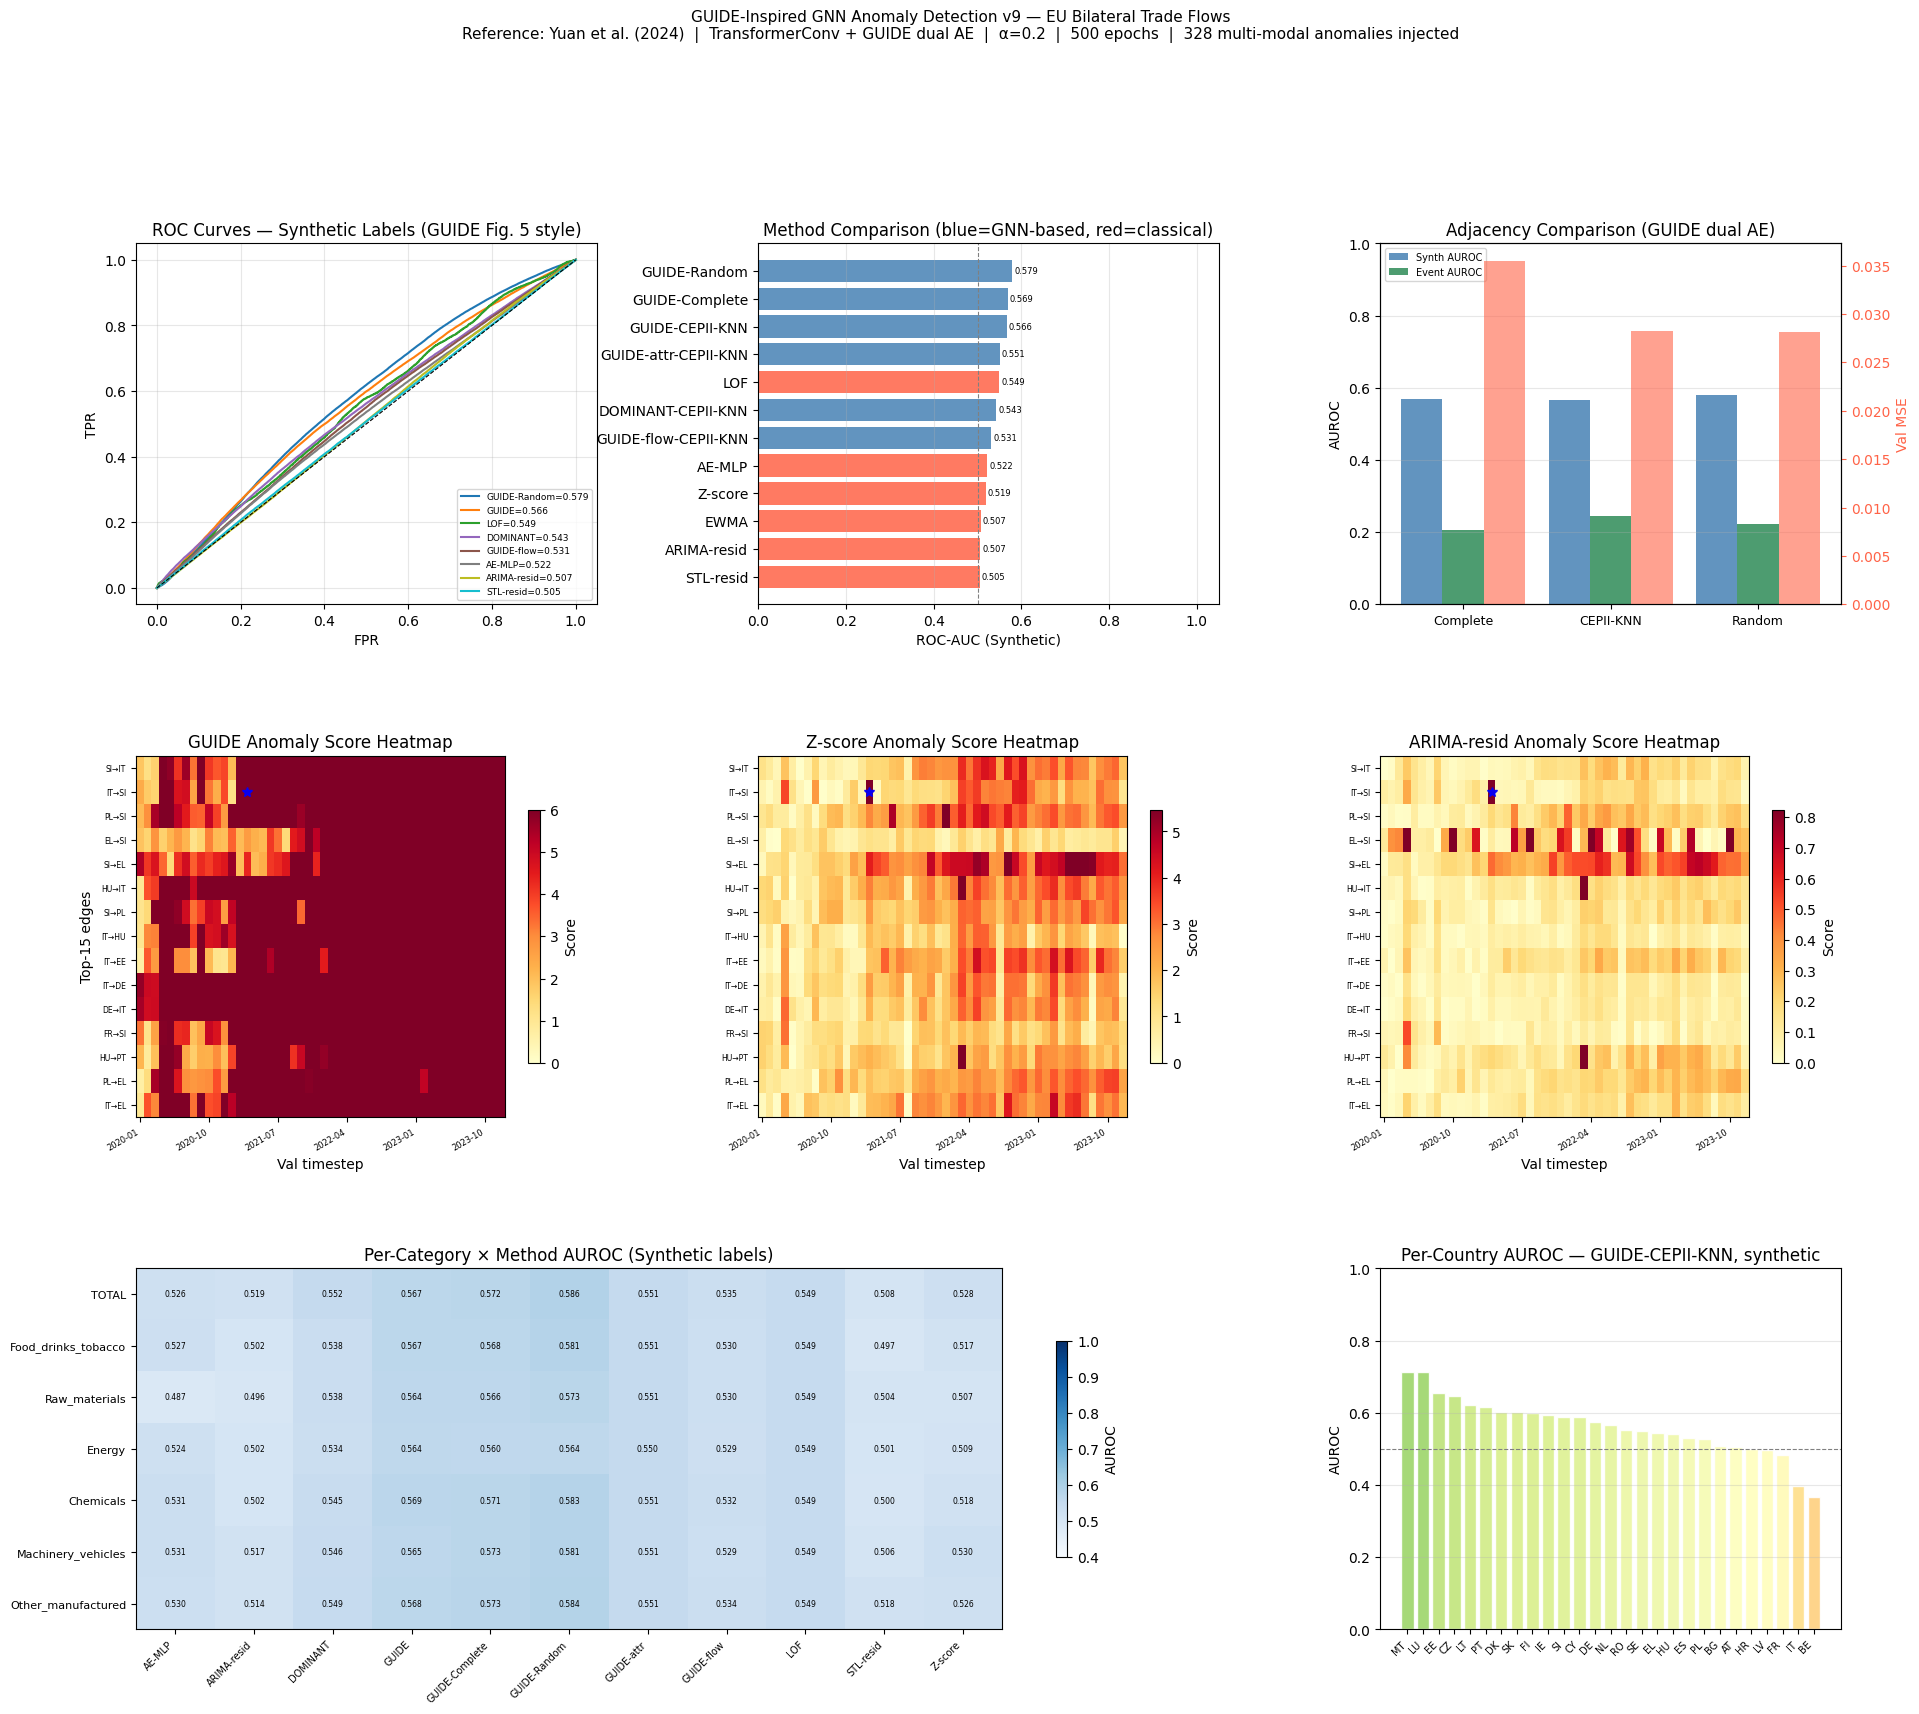

Saved: gnn_v9_guide_anomaly.png

✓ v9 complete


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell L — Visualisation (v9)
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(roc_curves)))
for (name, (fpr, tpr, auc)), col in zip(sorted(roc_curves.items(),
        key=lambda x: -(x[1][2] or 0)), colors_roc):
    short = name.replace(f"-{BEST_ADJ}","")
    ax1.plot(fpr, tpr, label=f"{short}={auc:.3f}", color=col, linewidth=1.5)
ax1.plot([0,1],[0,1],"k--", linewidth=0.8)
ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR")
ax1.set_title("ROC Curves — Synthetic Labels (GUIDE Fig. 5 style)")
ax1.legend(fontsize=6.5, loc="lower right"); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
guide_methods = [n for n in eval_all if "GUIDE" in n or "DOMINANT" in n]
class_methods = [n for n in eval_all if n not in guide_methods]
auroc_g = [(n, eval_all[n]["synth"]["auroc"] or 0) for n in guide_methods]
auroc_c = [(n, eval_all[n]["synth"]["auroc"] or 0) for n in class_methods]
all_sorted = sorted(auroc_g + auroc_c, key=lambda x: -x[1])
names_b = [n for n,_ in all_sorted]
vals_b  = [v for _,v in all_sorted]
cols_b  = ["steelblue" if "GUIDE" in n or "DOMINANT" in n else "tomato" for n in names_b]
bars = ax2.barh(names_b[::-1], vals_b[::-1], color=cols_b[::-1], alpha=0.85)
ax2.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax2.set_xlabel("ROC-AUC (Synthetic)")
ax2.set_title("Method Comparison (blue=GNN-based, red=classical)")
ax2.set_xlim(0, 1.05); ax2.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, vals_b[::-1]):
    ax2.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=6)

ax3 = fig.add_subplot(gs[0, 2])
adj_names  = list(ADJ_CONFIGS.keys())
sa  = [adj_results[a]["synth"]["auroc"] or 0 for a in adj_names]
ea_ = [adj_results[a]["event"]["auroc"] or 0 for a in adj_names]
mse = [adj_results[a]["val_mse"] for a in adj_names]
x   = np.arange(len(adj_names)); w = 0.28
ax3.bar(x-w,  sa,  w, label="Synth AUROC", color="steelblue", alpha=0.85)
ax3.bar(x,    ea_, w, label="Event AUROC", color="seagreen",  alpha=0.85)
ax3b = ax3.twinx()
ax3b.bar(x+w, mse, w, label="Val MSE",    color="tomato",    alpha=0.6)
ax3b.set_ylabel("Val MSE", color="tomato"); ax3b.tick_params(axis="y", colors="tomato")
ax3.set_xticks(x); ax3.set_xticklabels(adj_names, fontsize=9)
ax3.set_ylim(0, 1); ax3.set_ylabel("AUROC")
ax3.set_title("Adjacency Comparison (GUIDE dual AE)")
ax3.legend(loc="upper left", fontsize=7); ax3.grid(axis="y", alpha=0.3)

top_edges = np.argsort(label_synth.sum(axis=(0,2)))[-15:][::-1]
for plot_i, (method_key, ax_pos) in enumerate([
        (f"GUIDE-{BEST_ADJ}", gs[1,0]),
        ("Z-score",           gs[1,1]),
        ("ARIMA-resid",       gs[1,2])]):
    axh = fig.add_subplot(ax_pos)
    sc_slice = all_scores[method_key][:, top_edges, 0]
    vmax = min(ANOMALY_THRESH*2, np.nanpercentile(sc_slice, 99))
    im   = axh.imshow(sc_slice.T, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax)
    axh.set_xlabel("Val timestep"); axh.set_ylabel("Top-15 edges" if plot_i==0 else "")
    edge_labs = [f"{COUNTRIES[edge_pairs[e][0]]}→{COUNTRIES[edge_pairs[e][1]]}"
                 for e in top_edges]
    axh.set_yticks(range(15)); axh.set_yticklabels(edge_labs, fontsize=5.5)
    val_dates = [common_time[t+1].strftime("%Y-%m") for t in val_idx]
    step = max(1, n_val//5)
    axh.set_xticks(range(0, n_val, step))
    axh.set_xticklabels(val_dates[::step], fontsize=6, rotation=30, ha="right")
    plt.colorbar(im, ax=axh, shrink=0.7, label="Score")
    axh.set_title(f"{method_key.replace(f'-{BEST_ADJ}','')} Anomaly Score Heatmap")
    
    for vi, e_idx, c_idx in synth_indices:
        e_pos = list(top_edges).index(e_idx) if e_idx in top_edges else None
        if e_pos is not None and c_idx == 0:
            axh.plot(vi, e_pos, "b*", markersize=7, alpha=0.9)

ax5 = fig.add_subplot(gs[2, :2])
focus_methods = sorted([n for n in all_scores if
    any(k in n for k in ["GUIDE","DOMINANT","ARIMA","STL","Z-score","LOF","AE-MLP"])])
cat_auc = np.full((N_CATS, len(focus_methods)), np.nan)
for mi, mname in enumerate(focus_methods):
    sc_arr = all_scores[mname]
    for ci, cat in enumerate(ALL_CATS):
        sc = sc_arr[:,:,ci].reshape(-1); lb = label_synth[:,:,ci].reshape(-1).astype(int)
        ok = ~np.isnan(sc)
        if lb[ok].sum() > 0:
            cat_auc[ci, mi] = roc_auc_score(lb[ok],
                                             np.clip(sc[ok],0,np.percentile(sc[ok],99.9)))
im5 = ax5.imshow(cat_auc, aspect="auto", cmap="Blues", vmin=0.4, vmax=1.0)
ax5.set_xticks(range(len(focus_methods)))
ax5.set_xticklabels([n.replace(f"-{BEST_ADJ}","") for n in focus_methods],
                    rotation=45, ha="right", fontsize=7)
ax5.set_yticks(range(N_CATS)); ax5.set_yticklabels(ALL_CATS, fontsize=8)
for ci in range(N_CATS):
    for mi in range(len(focus_methods)):
        if not np.isnan(cat_auc[ci,mi]):
            ax5.text(mi, ci, f"{cat_auc[ci,mi]:.3f}", ha="center", va="center", fontsize=5.5)
plt.colorbar(im5, ax=ax5, shrink=0.6, label="AUROC")
ax5.set_title("Per-Category × Method AUROC (Synthetic labels)")

ax6 = fig.add_subplot(gs[2, 2])
c_sorted = sorted(country_aucs.items(), key=lambda x: -(x[1] or 0))
c_names  = [c for c,_ in c_sorted]; c_vals = [v or 0 for _,v in c_sorted]
bar_c = plt.cm.RdYlGn(np.array(c_vals))
ax6.bar(c_names, c_vals, color=bar_c, alpha=0.9, edgecolor="white")
ax6.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax6.set_xticklabels(c_names, rotation=45, ha="right", fontsize=7)
ax6.set_ylim(0, 1); ax6.set_ylabel("AUROC")
ax6.set_title(f"Per-Country AUROC — GUIDE-{BEST_ADJ}, synthetic")
ax6.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"GUIDE-Inspired GNN Anomaly Detection v9 — EU Bilateral Trade Flows\n"
    f"Reference: Yuan et al. (2024)  |  {BEST_CONV.__name__} + "
    f"GUIDE dual AE  |  α={ALPHA}  |  "
    f"{RECON_EPOCHS} epochs  |  {len(synth_indices)} multi-modal anomalies injected",
    fontsize=11, y=1.01
)
plt.savefig("gnn_v9_guide_anomaly.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: gnn_v9_guide_anomaly.png")
print("\n✓ v9 complete")